<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Deslocamentos transversais de vigas

### Problema 6

Considere a viga ABCD indicada na figura, simplesmente apoiada em A e D e suportando a carga concentrada $P=$ 150 kN aplicada em C. A viga é construída com um perfil de aço HEB 260, com $E= 210$ GPa, e a folga que existe entre a face inferior da viga e o rolete colocado sob a secção B antes da carga $P$ ser aplicada é $\delta_B=$ 3 mm.

a) Determine as reações nos apoios quando a carga P é aplicada.

b) Trace os diagramas do esforço transverso e do momento fletor.

c) Determine a equação da linha elástica.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au09/P6/MSII_Au09_P6.png"
width="600">


In [13]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '1'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

# data structure, units: N, mm, MPa

class varin: pass

d = varin()
HEB260 = varin()

d.AB = 2.  # unit: m
d.BC = 1.  # unit: m
d.CD = 1.  # unit: m

d.AC = d.AB + d.BC
d.AD = d.AC + d.CD
d.BD = d.BC + d.CD

d.P = 150.e3  # unit: N
d.E = 210.e9 # Pa
d.deltaB = 3.e-3 # m

HEB260.b = 260. # unit: mm
HEB260.h = 260. # unit: mm
HEB260.A = 11800. # unit: mm2
HEB260.Iz = 149.e6 # unit: mm4

HEB260.EI = (HEB260.Iz*1e-12)*d.E # m4.N/m2
print(f'HEB260.EI = {HEB260.Iz*1e-12:.3e}({d.E:.1e}) = {HEB260.EI:.4e} [N.m2]')

HEB260.EI = 1.490e-04(2.1e+11) = 3.1290e+07 [N.m2]


## Resolução

###   a) Determine as reações nos apoios quando a carga P é aplicada.

##### Verificação se a viga ao fletir toca no suporte em B

De notar que a viga deforma-se em flexão devido à carga $P$ aplicada no ponto C. A questão é se a viga irá entretanto apoiar-se no ponto B. Nesse cenário ocorrerá uma força de reação no apoio em B.

- 1 ::: Determinação da equação da linha elástica da viga ABCD devido à carga $P$.

- Cálculo das reações nos apoios duplo em A e simples em D

In [14]:
rax, ray, rdy = sy.symbols('rax ray rdy')

print('::: sistema de equações :::')
sumFX = rax
print(f'sumFX = {sumFX} [N]')
sumFY = ray + rdy - d.P
print(f'sumFY = {sumFY} [N]')
sumMD= d.P*d.CD - ray*d.AD
print(f'sumMD = {sumMD} [N.m]')
sol = solve([sumFX,sumFY,sumMD],[rax, ray, rdy])

print('::: resolução :::')
RAx = sol[rax]; print(f'RAx = {RAx} [kN]')
RAy = sol[ray]; print(f'RAy = {RAy:.1f} [kN]')
RDy = sol[rdy]; print(f'RDy = {RDy:.1f} [kN]')

::: sistema de equações :::
sumFX = rax [N]
sumFY = ray + rdy - 150000.0 [N]
sumMD = 150000.0 - 4.0*ray [N.m]
::: resolução :::
RAx = 0.0 [kN]
RAy = 37500.0 [kN]
RDy = 112500.0 [kN]


- Aplicação do método das secções para a determinação da expressão do momento fletor (troço AB)

\begin{equation*}
\sum M = 0
\quad\Leftrightarrow\quad
- R_{Ay}x + M(x) = 0
\quad\Leftrightarrow\quad
M(x) = \frac{P}{4}x
\end{equation*}

In [15]:
x, mab = sy.symbols('x mab')
print(f':: momento fletor troço AB ::')
EqMAx = -RAy*x + mab
print(f'EqMAx = {EqMAx} [N.mm]')
sol = solve(EqMAx,mab)
MAB = sol[0]
print(f'MB = {MAB} [N.mm]')

:: momento fletor troço AB ::
EqMAx = mab - 37500.0*x [N.mm]
MB = 37500.0*x [N.mm]


- Equação da linha elástica (troço AB)

\begin{equation*}
EI \frac{\mathrm{d}²y}{\mathrm{d}x²} = M(x) = \frac{P}{4}x
\end{equation*}

Por integração resulta,

\begin{equation*}
EI \frac{\mathrm{d}y}{\mathrm{d}x} = EI \theta(x) = \frac{P}{4}\left(\frac{x²}{2}\right) + C_1
\end{equation*}

Integrando novamente,

\begin{equation*}
EI y(x) = \frac{P}{24}x³ + C_1 x + C_2
\end{equation*}

As constantes de integração são determinadas pelas condições de fronteira pela compatibilidade de deslocamentos:

\begin{equation*}
y(x=0) = 0
\quad\Rightarrow\quad  C_2 = 0
\end{equation*}

\begin{equation*}
y(x=L_{AD}) = 0
\quad\Rightarrow\quad  \frac{P}{24} (L_{AD})³ + C_1 (L_{AD}) = 0
\end{equation*}

In [25]:
c1, c2 = sy.symbols('c1 c2')

print('::: eq. cond. fronteira :::')

def flex(x):
    return d.P/24*x**3 + c1*x + c2

eqC1 = flex(0.)
sol = solve(eqC1,c2)
C2 = sol[0]
print(f'eqC2 = {eqC1} | C2 = {C2}')

eqC2 = flex(d.AD).subs(c2,C2)
sol = solve(eqC2,c1)
C1 = sol[0]
print(f'eqC2 = {eqC2} | C1 = {C1:.1f} ')

def theta_(x):
    return sy.diff(flex(x).subs({(c1,C1),(c2,C2)}),x)/HEB260.EI

def y_(x):
    return flex(x).subs({(c1,C1),(c2,C2)})/HEB260.EI

yB_P = y_(d.AB)
print(f'\ny(x) = {flex(x).subs({c1:C1, c2:C2})} [m]')
print(f'\nyB(P) = {yB_P:.3e} [m] = {yB_P*1e3:.3f} [mm] > delta B (imposto)')

ola
::: eq. cond. fronteira :::
eqC2 = c2 | C2 = 0
eqC2 = 4.0*c1 + 400000.0 | C1 = -100000.0 

y(x) = 6250.0*x**3 - 100000.0*x [m]

yB(P) = -4.794e-3 [m] = -4.794 [mm] > delta B (imposto)


#### Estrutura hiperelástica

Como $y_B$ devido à carga $P$ é superior a $\delta_B=$ 3 mm, a viga irá apoiar sobre o suporte B criando uma força de reação vertical, $R_{By}$


- Cálculo das reações em A, B e D

\begin{equation*}
\sum F_x = 0
\quad\wedge\quad
\sum F_y = 0
\quad\wedge\quad
\sum M_A = 0
\end{equation*}

\begin{equation*}
\begin{cases}
R_{Ax} = 0 \\
R_{Ay} + R_{By} - P + R_{Dy} = 0 \\
R_{By}L_{AB} - PL_{AC} + R_{Dy}L_{AD} = 0
\end{cases}
\end{equation*}

In [17]:
rax2, ray2, rby, rdy2 = sy.symbols('rax2 ray2 rby rdy2')

print('::: sistema de equações :::')
sumFX2 = rax2
print(f'sumFX = {sumFX2} [N]')
sumFY2 = ray2 + rby - d.P + rdy2
print(f'sumFY = {sumFY2} [N]')
sumMA2= rby*d.AB -d.P*d.AC + rdy2*d.AD
print(f'sumMA = {sumMA2} [N.m]')

::: sistema de equações :::
sumFX = rax2 [N]
sumFY = ray2 + rby + rdy2 - 150000.0 [N]
sumMA = 2.0*rby + 4.0*rdy2 - 450000.0 [N.m]


- De notar que o problema em análise é hiperestático de 1º grau. Portanto, para além das equações de equilíbrio, é necessário definir uma expressão adicional. Neste caso, essa expressão pode ser definida pela equação da linha elástica e a condição cinemática de admissibilidade no apoio em B.

O diagrama de corpo livre da vida ABCD contem nesta análise 4 forças:
 
- reações em A, $R_{Ax},R_{Ay}$, 
- reação em B, $R_{By}$, 
- a força diretamente aplicada em C, $P$
- a reação em D, $R_{Dy}$.

A expressão do momento fletor, $M(x)$, em termos de funções de singularidade vem

\begin{equation*}
M(x) = R_{Ay} x + R_{By} <x-L_{AB}>¹ - P<x-L_{AC}>¹
\end{equation*}

Pelo que a expressão da linha elástica resulta,

\begin{equation*}
EI \frac{\mathrm{d}² y(x)}{\mathrm{d} x²} = M(x) = R_{Ay} x + R_{By} <x-L_{AB}>¹ - P<x-L_{AC}>¹
\end{equation*}

Por integração obtem-se,

\begin{equation*}
EI \frac{\mathrm{d} y(x)}{\mathrm{d} x} = EI \theta(x) = \frac{R_{Ay}}{2}x² + \frac{R_{By}}{2} <x-L_{AB}>² - \frac{P}{2} <x-L_{AC}>² + C_3
\end{equation*}

Integrando novamente,

\begin{equation*}
EI y(x) = \frac{R_{Ay}}{6}x³ + \frac{R_{By}}{6} <x-L_{AB}>³ - \frac{P}{6} <x-L_{AC}>³ + C_3 x + C_4
\end{equation*}

As condições de fronteira são,

\begin{equation*}
y(0) = 0 \quad\Rightarrow\quad y(0) = C_4 = 0
\end{equation*}

\begin{equation*}
y(x=L_{AB}) = \left[\frac{R_{Ay}}{6}(L_{AB})³ + C_3 L_{AB}\right] / EI =
\delta_B
\end{equation*}

\begin{equation*}
y(x=L_{AD}) = \frac{R_{Ay}}{6}(L_{AD})³ + \frac{R_{By}}{6} (L_{AD}-L_{AB})³ - \frac{P}{6} (L_{AD}-L_{AC})³ + C_3 (L_{AD}) = 0
\end{equation*}

Desta forma é possível construir o seguinte sistema de equações,

\begin{equation*}
\begin{cases}
R_{Ax} = 0 \\
R_{Ay} + R_{By} - P + R_{Dy} = 0 \\
R_{By}L_{AB} - PL_{AC} + R_{Dy}L_{AD} = 0 \\
\left[\frac{R_{Ay}}{6}(L_{AB})³ + C_3 L_{AB}\right] / EI = \delta_B \\
\frac{R_{Ay}}{6}(L_{AD})³ + \frac{R_{By}}{6} (L_{AD}-L_{AB})³ - \frac{P}{6} (L_{AD}-L_{AC})³ + C_3 (L_{AD}) = 0
\end{cases}
\end{equation*}

In [18]:
c3 = sy.symbols('c3')
eqE1 = (ray2/6*d.AB**3 + c3*d.AB)/HEB260.EI - d.deltaB
print(f'eqE1 = {eqE1}')
eqE2 = ray2/6*d.AD**3 + rby/6*(d.AD-d.AB)**3 - d.P/6*(d.AD-d.AC)**3 + c3*d.AD
print(f'eqE2 = {printsymSF(eqE2)}')

sol = solve([sumFX2,sumFY2,sumMA2,eqE1,eqE2],[rax2, ray2, rby, rdy2, c3])

print('::: resolução :::')
RAx2 = sol[rax2]; print(f'RAx = {RAx2} [kN]')
RAy2 = sol[ray2]; print(f'RAy = {RAy2*1e-3:.1f} [kN]')
RBy = sol[rby]; print(f'RBy = {RBy*1e-3:.1f} [kN]')
RDy2 = sol[rdy2]; print(f'RDy = {RDy2*1e-3:.1f} [kN]')
C3 = sol[c3]; print(f'C3 = {C3*1e-3:.3f} [kN.m2]')

eqE1 = 6.39181847235539e-8*c3 + 4.26121231490359e-8*ray2 - 0.003
eqE2 = 4.0*c3 + 10.667*ray2 + 1.333*rby - 25000.0
::: resolução :::
RAx = 0.0 [kN]
RAy = -49.3 [kN]
RBy = 173.5 [kN]
RDy = 25.7 [kN]
C3 = 79.777 [kN.m2]


### b) Trace os diagramas do esforço transverso e do momento fletor.

É possível agora definir as expressões dos esforços transverso e momento fletor por funções de singularidade

\begin{equation*}
M(x) = R_{Ay} x + R_{By} <x-L_{AB}>¹ - P<x-L_{AC}>¹
\end{equation*}

Por derivação,

\begin{equation*}
V(x) = \frac{\mathrm{d}M(x)}{\mathrm{d}x} = R_{Ay} + R_{By} <x-L_{AB}>^0 - P<x-L_{AC}>^0
\end{equation*}


In [19]:
VAB = RAy2
print(f'VAB = {VAB*1e-3:.1f} [kN]')
VBC = RAy2 + RBy
print(f'VBC = {VBC*1e-3:.1f} [kN]')
VCD = RAy2 + RBy - d.P
print(f'VCD = {VCD*1e-3:.1f} [kN]')

VAB = -49.3 [kN]
VBC = 124.3 [kN]
VCD = -25.7 [kN]


In [20]:
MAB = RAy2*x
print(f'MAB = {printsymSF(MAB*1e-3)} [kN.m]')
MBC = RAy2*x + RBy*(x-d.AB)
print(f'MBC = {printsymSF(MBC*1e-3)} [kN.m]')
MCD = RAy2*x + RBy*(x-d.AB) - d.P*(x-d.AC)
print(f'MCD = {printsymSF(MCD*1e-3)} [kN.m]')

MAB = -49.264*x [kN.m]
MBC = 124.264*x - 347.055 [kN.m]
MCD = 102.945 - 25.736*x [kN.m]


In [21]:
xAB = np.linspace(0,d.AB)
xBC = np.linspace(d.AB,d.AC)
xCD = np.linspace(d.AC,d.AD)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
yVAB = sy2array(VAB*1e-3,xAB)
yMAB = sy2array(MAB*1e-3,xAB)

# BC
yVBC = sy2array(VBC*1e-3,xBC)
yMBC = sy2array(MBC*1e-3,xBC)

# CD
yVCD = sy2array(VCD*1e-3,xCD)
yMCD = sy2array(MCD*1e-3,xCD)

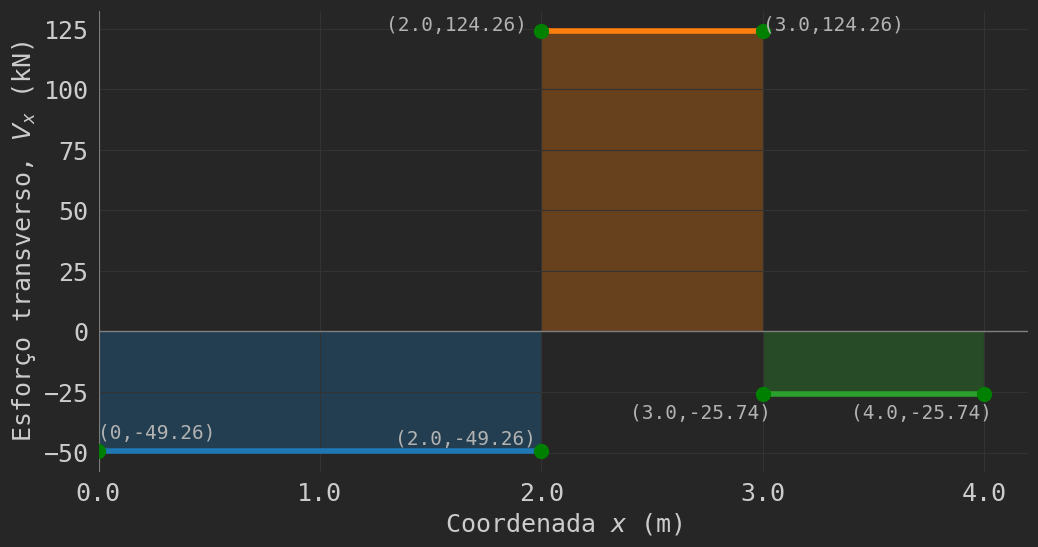

In [22]:
fz = 14

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4)
plt.fill_between(xAB,yVAB, alpha=.3)
plt.plot(xBC,yVBC,linewidth=4)
plt.fill_between(xBC,yVBC, alpha=.3)
plt.plot(xCD,yVCD,linewidth=4)
plt.fill_between(xCD,yVCD, alpha=.3)
plt.xlabel('Coordenada $x$ (m)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[0]*1.,yVAB[0]*.9,f'({xAB[0]:.0f},{yVAB[0]:.2f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
plt.text(xAB[-1]*.67,yVAB[-1]*.95,f'({xAB[-1]:.1f},{yVAB[-1]:.2f})',fontsize=fz)
plt.plot(xBC[0],yVBC[0],'go',markersize=10)
plt.text(xBC[0]*.65,yVBC[0]*1.,f'({xBC[0]:.1f},{yVBC[0]:.2f})',fontsize=fz)
plt.plot(xBC[-1],yVBC[-1],'go',markersize=10)
plt.text(xBC[-1]*1.,yVBC[-1]*1.,f'({xBC[-1]:.1f},{yVBC[-1]:.2f})',fontsize=fz)
plt.plot(xCD[0],yVCD[0],'go',markersize=10)
plt.text(xCD[0]*.8,yVCD[0]*1.4,f'({xCD[0]:.1f},{yVCD[0]:.2f})',fontsize=fz)
plt.plot(xCD[-1],yVCD[-1],'go',markersize=10)
plt.text(xCD[-1]*.85,yVCD[-1]*1.4,f'({xCD[-1]:.1f},{yVCD[-1]:.2f})',
         fontsize=fz)
plt.xlim(0,d.AD*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
xrang = np.arange(0, d.AD*1.1, 1.)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# plt.ylim(-int(P4.p2*2),int(P4.p2*2))
plt.grid(True)
plt.show()

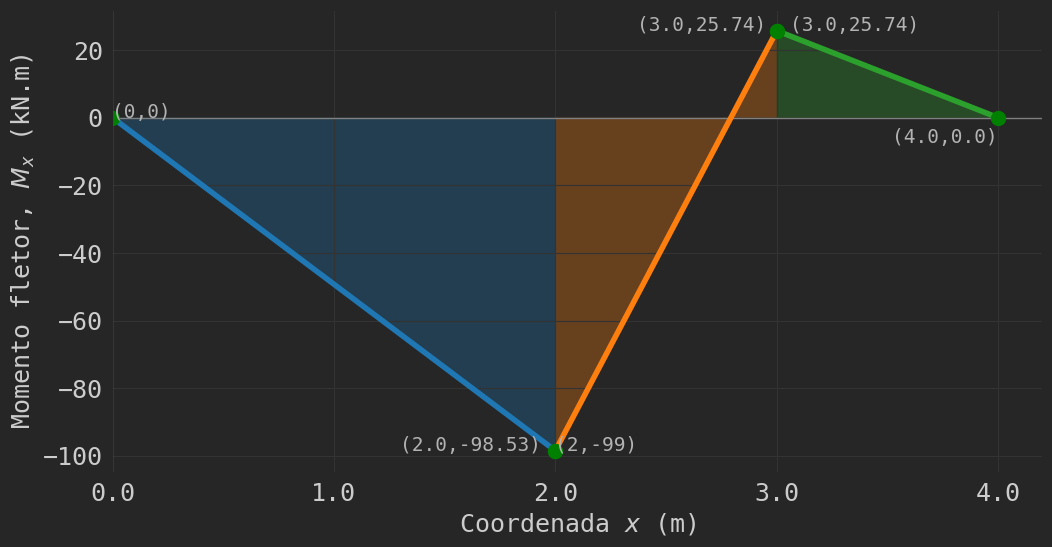

In [23]:
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4)
plt.fill_between(xAB,yMAB, alpha=.3)
plt.plot(xBC,yMBC,linewidth=4)
plt.fill_between(xBC,yMBC, alpha=.3)
plt.plot(xCD,yMCD,linewidth=4)
plt.fill_between(xCD,yMCD, alpha=.3)
plt.xlabel(r'Coordenada $x$ (m)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[0],yMAB[0]+.1,f'({xAB[0]:.0f},{yMAB[0]:.0f})',fontsize=fz)
plt.plot(xAB[-1],yMAB[-1],'go',markersize=10)
plt.text(xAB[-1]*1.,yMAB[-1]+.1,f'({xAB[-1]:.0f},{yMAB[-1]:.0f})',fontsize=fz)
plt.plot(xBC[0],yMBC[0],'go',markersize=10)
plt.text(xBC[0]*.65,yMBC[0]*1.,f'({xBC[0]:.1f},{yMBC[0]:.2f})',fontsize=fz)
plt.plot(xBC[-1],yMBC[-1],'go',markersize=10)
plt.text(xBC[-1]*1.02,yMBC[-1]*1.,f'({xBC[-1]:.1f},{yMBC[-1]:.2f})', fontsize=fz)
plt.plot(xCD[0],yMCD[0],'go',markersize=10)
plt.text(xCD[0]*.79,yMCD[0]*1.,f'({xCD[0]:.1f},{yMCD[0]:.2f})',fontsize=fz)
plt.plot(xCD[-1],yMCD[-1],'go',markersize=10)
plt.text(xCD[-1]*.88,yMCD[-1]-7.5,f'({xCD[-1]:.1f},{yMCD[-1]:.1f})', fontsize=fz)
plt.xlim(0,d.AD*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.AD*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

###  c) Determine a equação da linha elástica.


- Equação da linha elástica:

\begin{equation*}
\frac{\partial² y}{\partial x²} = \frac{M(x)}{EI}
\end{equation*}

com,

\begin{equation*}
M(x) = R_{Ay} x + R_{By} <x-L_{AB}>¹ - P<x-L_{AC}>¹
\end{equation*}

Por dupla integração e como desenvolvido na alínea b) resulta

\begin{equation*}
y(x) = \left[\frac{R_{Ay}}{6}x³ + \frac{R_{By}}{6} <x-L_{AB}>³ - \frac{P}{6} <x-L_{AC}>³ + C_3 x \right]/EI
\end{equation*}

flexAB = 0.003*x
flexBC = 0.001*x**3 - 0.006*x**2 + 0.014*x - 0.007
flexCD = 0.002*x**2 - 0.008*x + 0.014


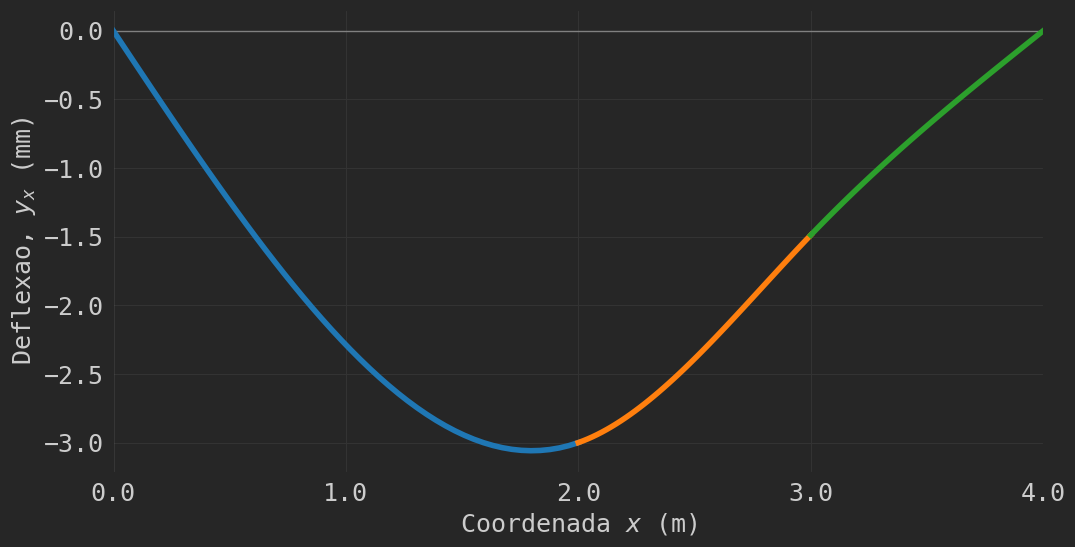

In [24]:
flexAB = ( RAy2/6*x**3 + C3*x )/HEB260.EI
print(f'flexAB = {printsymSF(flexAB)}')
flexBC = ( RAy2/6*x**3 + RBy/6*(x-d.AB)**3 + C3*x )/HEB260.EI
print(f'flexBC = {printsymSF(flexBC)}')
flexCD = ( RAy2/6*x**3 + RBy/6*(x-d.AB)**3 - d.P/6*(x-d.AC)**3 + C3*x )/HEB260.EI
print(f'flexCD = {printsymSF(flexCD)}')

# AB
yflexAB = sy2array(-flexAB*1e3,xAB)
# BC
yflexBC = sy2array(-flexBC*1e3,xBC)
# CD
yflexCD = sy2array(-flexCD*1e3,xCD)

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yflexAB,linewidth=4)
plt.plot(xBC,yflexBC,linewidth=4)
plt.plot(xCD,yflexCD,linewidth=4)
plt.xlabel(r'Coordenada $x$ (m)')
plt.ylabel(r'Deflexao, $y_{x}$ (mm)')
plt.xlim(0,2e-3)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.AD*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

## Apêndice: Equação da elástica

A equação $y(x)$ descreve a localização do eixo da viga na posição deformada pela acção do momento fletor. Esta equação é conhecida como equação da linha elástica, e pode ser obtida na prática por dupla integração da equação do momento fletor ao longo da viga. A equação resultante deve ainda satisfazer as condições de fronteira do problema, ou seja, ser cinematicamente admissível. Esta condição permitirá determinar nomeadamente as constantes de integração resultantes do processo matemática de integração.

A hipótese de Euler-Bernoulli para o problema de flexão de uma viga conduz à seguinte equação,

\begin{equation*}
\varepsilon_{xx} = -\frac{y}{\rho}
\end{equation*}

Assumindo ainda a lei de Hooke para o comportamento linear elástico do materia, $\sigma_{xx} = E \varepsilon_{xx}$, pode obter-se uma relação entre o momento flector $M(x)$ e o raio de curvatura da superfície neutra da viga $\rho$,

\begin{equation*}
\sigma_{xx} = E \varepsilon_{xx} =
-\frac{yE}{\rho}
\quad\wedge\quad
\sigma_{xx} = -\frac{My}{I_z}
\quad\therefore\quad
\frac{1}{\rho} = \frac{M}{EI_z}
\end{equation*}

Considerando agora a relação entre o raio de curvatura $\rho$ e as segundas derivadas da função $y(x)$, que para pequenos valroes resulta,

\begin{equation*}
\frac{1}{\rho} \approx \frac{\mathrm{d}² y}{\mathrm{d} x²}
\end{equation*}

obtém-se finalmente,

\begin{equation*}
\frac{\mathrm{d}² y}{\mathrm{d} x²}
= \frac{M}{EI_z}
\end{equation*}

Assim sendo, para se obter a equação da elástica da viga do problema, $y(x)$, é necessário:

1. Escrever a equação do momento fletor na viga, M(x) - nomeadamente usando funções de singularidasde;

2. Integrar duas vezes essa equação;

3. Aplicar condições fronteira para calcular as duas constantes que surgem durante a integração.